# MOP target selection with Rubin coverage

This notebook selects visible MOP targets, queries their coverage in the selected Rubin Data Release, and generates tables, maps, and individual reports. Run the sections in order.


## 1. Configuration

Choose the Data Release, dates, observatory, and output directory. MOP, TAP, and Butler connections are created automatically when the pipeline runs.


In [1]:
from importlib import reload
from pathlib import Path

import pandas as pd
import mop_photometry
import release_photometry
import monitoring_report
import target_report
import target_selection_pipeline as pipeline

# Reload every module used by the reports when rerunning the notebook.
reload(mop_photometry)
reload(release_photometry)
reload(monitoring_report)
reload(target_report)
reload(pipeline)
run_target_selection = pipeline.run_target_selection

DATA_RELEASE_NAME = "DP2"  # DP0.1, DP0.2, DP1, or DP2
START_DATE = "2026-08-09"
END_DATE = "2026-08-18"
OUTPUT_DIR = Path("outputs")
OBSERVATORY = "El Leoncito"

# Keep False to resume an interrupted run; set True only to remake every report.
OVERWRITE_TARGET_PLOTS = False
GENERATE_TARGET_REPORTS = False  # Set True when individual target dashboards are needed.
# "all_queried" or "visibility_selected" (passes the local visibility filter on at least one night).
TARGET_REPORT_SCOPE = "visibility_selected"
# "all_queried" evaluates every Rubin-query target each night; "mop_daily" evaluates only nightly MOP candidates.
VISIBILITY_TARGET_SCOPE = "all_queried"

# Sky-map options
SKY_MARKER_ENCODING = "split_color"  # "split_color" or "color_size"
SHOW_COVERAGE_BACKGROUND = True
COVERAGE_RESOLUTION = 30  # Coarse cells, approximately one LSSTCam FoV

# Visibility plot options
GENERATE_VISIBILITY_PLOTS = True
VISIBILITY_MINIMUM_ALTITUDE = 40
VISIBILITY_MINIMUM_OBSERVABLE_MINUTES = 30
VISIBILITY_SEQUENCE_FORMAT = "pdf"  # "pdf" or "png"
VISIBILITY_X_REFERENCE_EVERY = 4
VISIBILITY_TIME_STEP_MINUTES = 1
# Local allocated observing time. Each ISO date is the evening that starts the night.
# Use one pair for every night, or a default with night-specific overrides.
OBSERVING_WINDOWS = {
    "default": ("20:30", "07:00"),
    # "2026-08-10": ("21:30", "03:00"),
    # "2026-08-11": [("18:00", "23:00"), ("02:00", "06:00")],
    # "2026-08-12": [],  # No allocated time.
}
OVERWRITE_VISIBILITY_PLOTS = True

# Rubin coadd forced photometry. Early DP2 has no individual calibrated exposures,
# so PSF fluxes are measured at each target coordinate on the available deep coadds.
# Set the target list to None to measure every selected target.
GENERATE_RELEASE_PHOTOMETRY = False
RELEASE_PHOTOMETRY_TARGETS = None  # Example: ["OGLE-2026-BLG-0001"]
OVERWRITE_RELEASE_PHOTOMETRY = False

# Optional HSH summary for previously observed targets.
HSH_IMAGE_CATALOG = Path("hsh_data/image_collection_astro.csv")
#if not HSH_IMAGE_CATALOG.exists():
#    HSH_IMAGE_CATALOG = None
REFRESH_HSH_DATA = True  # Re-import image_collection_astro.csv into the local registry.
MAX_CURRENT_MAGNITUDE = 16  # Example: 18.5; missing MOP magnitudes are retained.
HSH_PEAK_HALF_WIDTH_T_E = 0.3
HSH_EVENT_HALF_WIDTH_T_E = 2.0

# Multipage PDF: MOP light curves with DP2, HSH, and JS epochs.
GENERATE_MONITORING_REPORT = True
MONITORING_REPORT_PLOTS_PER_PAGE = 3
# Select any subset of: mop_photometry, release_epochs, hsh, js.
MONITORING_LAYERS = ("mop_photometry", "release_epochs", "hsh", "js")

# Query Rubin for MOP-visible, configured local-survey, and optional user-supplied events.
INCLUDE_PREVIOUSLY_OBSERVED = True
# Providers included when querying previously observed targets.
PREVIOUSLY_OBSERVED_PROVIDERS = ("HSH", "JS")
# Optional DataFrame or CSV path with Target, RA_deg, and Dec_deg.
ADDITIONAL_TARGETS = None
SHOW_QUERIED_TARGETS = True  # Print every target sent to the Rubin coverage query.


## 2. Run the pipeline

Each MOP page is downloaded once with limited concurrency and provides both parameters and photometry. CSV files, MOP pages, 404 responses, photometry, Rubin coverage queries, and plots are cached; the cell reports progress by stage. If a run is interrupted, keep `reuse_cache=True` and all `OVERWRITE_*` settings `False`, then rerun this cell: completed stages and current reports are reused. Use `reuse_cache=False` only to force fresh data.


In [2]:
combined, paths = run_target_selection(
    start_date=START_DATE,
    end_date=END_DATE,
    data_release=DATA_RELEASE_NAME,
    root_dir=OUTPUT_DIR,
    observatory=OBSERVATORY,
    max_workers=4,
    reuse_cache=True,
    overwrite_target_plots=OVERWRITE_TARGET_PLOTS,
    target_report_scope=TARGET_REPORT_SCOPE,
    target_plotter=None if GENERATE_TARGET_REPORTS else False,
    visibility_target_scope=VISIBILITY_TARGET_SCOPE,
    sky_marker_encoding=SKY_MARKER_ENCODING,
    show_coverage_background=SHOW_COVERAGE_BACKGROUND,
    coverage_resolution=COVERAGE_RESOLUTION,
    generate_visibility_plots=GENERATE_VISIBILITY_PLOTS,
    visibility_minimum_altitude=VISIBILITY_MINIMUM_ALTITUDE,
    visibility_minimum_observable_minutes=VISIBILITY_MINIMUM_OBSERVABLE_MINUTES,
    visibility_time_step_minutes=VISIBILITY_TIME_STEP_MINUTES,
    visibility_observing_windows=OBSERVING_WINDOWS,
    overwrite_visibility_plots=OVERWRITE_VISIBILITY_PLOTS,
    generate_release_photometry=GENERATE_RELEASE_PHOTOMETRY,
    release_photometry_targets=RELEASE_PHOTOMETRY_TARGETS,
    overwrite_release_photometry=OVERWRITE_RELEASE_PHOTOMETRY,
    hsh_image_catalog=HSH_IMAGE_CATALOG,
    refresh_hsh_data=REFRESH_HSH_DATA,
    max_current_magnitude=MAX_CURRENT_MAGNITUDE,
    hsh_peak_half_width_t_e=HSH_PEAK_HALF_WIDTH_T_E,
    hsh_event_half_width_t_e=HSH_EVENT_HALF_WIDTH_T_E,
    generate_monitoring_report=GENERATE_MONITORING_REPORT,
    monitoring_report_plots_per_page=MONITORING_REPORT_PLOTS_PER_PAGE,
    monitoring_layers=MONITORING_LAYERS,
    include_previously_observed=INCLUDE_PREVIOUSLY_OBSERVED,
    previously_observed_providers=PREVIOUSLY_OBSERVED_PROVIDERS,
    additional_targets=ADDITIONAL_TARGETS,
    show_queried_targets=SHOW_QUERIED_TARGETS,
    verbose=True,
)

print(f"Targets processed: {len(combined)}")
print(f"Products saved to: {paths['run'].resolve()}")
combined.head()


      Imported 18873 HSH astrometry records
[1/5] Visible MOP targets
      Excluded 518 MOP candidate(s) by the magnitude cut
[2/5] MOP parameters + photometry
      Excluded 13 previously observed target(s) with MOP mag_now <= 0
      Visibility selection (all_queried: 160 target-night rows)


/home/karennowo/target_selection/target_selection_pipeline.py:1136: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([visible_summary, observed_only, user_targets], ignore_index=True, sort=False)


      Nightly visibility plots
      visibility: 1/10 (2026-08-09, 16/16 selected)
      visibility: 2/10 (2026-08-10, 16/16 selected)
      visibility: 3/10 (2026-08-11, 16/16 selected)
      visibility: 4/10 (2026-08-12, 16/16 selected)
      visibility: 5/10 (2026-08-13, 16/16 selected)
      visibility: 6/10 (2026-08-14, 16/16 selected)
      visibility: 7/10 (2026-08-15, 16/16 selected)
      visibility: 8/10 (2026-08-16, 16/16 selected)
      visibility: 9/10 (2026-08-17, 16/16 selected)
      visibility: 10/10 (2026-08-18, 16/16 selected)
      Rubin query targets: 16 (0 MOP-visible, 16 previously observed only, 0 user supplied)
        Gaia23cnu, Gaia23dpn, OGLE-2024-BLG-0002, OGLE-2024-BLG-0592, OGLE-2024-BLG-0605
        OGLE-2024-BLG-0669, OGLE-2024-BLG-0674, OGLE-2024-DG-0016, OGLE-2024-GD-0014, OGLE-2025-BLG-0245
        OGLE-2025-BLG-0397, OGLE-2025-BLG-0451, OGLE-2025-BLG-0675, OGLE-2025-BLG-0681, OGLE-2025-BLG-0715
        OGLE-2025-BLG-1480
[3/5] DP2 coverage (run cach

/home/karennowo/target_selection/target_selection_pipeline.py:1195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mop_visible = queried_targets["is_mop_visible_in_run"].fillna(False).astype(bool)


      Observing selection summary
      Monitoring light-curve PDF
Pipeline completed in 2.3 min
Targets processed: 16
Products saved to: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00


,Target,RA,Dec,Site,Min airmass,mag_now_x,tap_priority,tap_priority_longte,mop_link,observation_date,...,hsh_peak_n,hsh_fall_n,hsh_post_baseline_n,hsh_unknown_n,hsh_n_V,hsh_exptime_V_s,hsh_n_I,hsh_exptime_I_s,hsh_n_N,hsh_exptime_N_s
0,Gaia23cnu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,...,0,0,0,165,84,9270.0,81,8730.0,0,NaN
1,Gaia23dpn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,...,0,0,0,27,14,4200.0,13,3900.0,0,NaN
2,OGLE-2024-BLG-0002,NaN,NaN,NaN,NaN,15.755373,NaN,NaN,https://mop.lco.global/targets/42779/,NaN,...,0,0,0,0,37,6090.0,36,5910.0,0,NaN
3,OGLE-2024-BLG-0592,NaN,NaN,NaN,NaN,14.590973,NaN,NaN,https://mop.lco.global/targets/44846/,NaN,...,1502,366,0,0,744,58330.0,1684,124680.0,0,NaN
4,OGLE-2024-BLG-0605,NaN,NaN,NaN,NaN,15.890718,NaN,NaN,https://mop.lco.global/targets/44960/,NaN,...,139,693,0,0,355,23040.0,477,31020.0,0,NaN


## 3. Explore the results

The following cells display the main products without manually browsing the output directories.


In [3]:
from IPython.display import Image, Markdown, display
target_summary = pd.read_csv(paths["tables"] / "target_summary.csv")
n_visible = len(target_summary)
n_coverage = int(target_summary["matched_release"].fillna(False).sum())
n_photometry = int(target_summary["mop_photometry_points"].fillna(0).gt(0).sum())
n_both = int(target_summary["matched_with_photometry"].fillna(False).sum())
display(Markdown(
    f"### Run summary\n"
    f"- **Data Release:** {DATA_RELEASE_NAME}\n"
    f"- **Visible targets:** {n_visible}\n"
    f"- **With {DATA_RELEASE_NAME} coverage:** {n_coverage}\n"
    f"- **With MOP photometry:** {n_photometry}\n"
    f"- **With coverage and photometry:** {n_both}\n"
    f"- **Directory:** {paths['run'].resolve()}"
))
queried_targets = pd.read_csv(paths["tables"] / "queried_targets.csv")
display(Markdown(f"### Rubin query targets ({len(queried_targets)})"))
with pd.option_context("display.max_rows", None):
    display(queried_targets.sort_values(["query_source", "Target"]))
print(f"Saved to: {(paths['tables'] / 'queried_targets.csv').resolve()}")

summary_columns = [
    "Target", "priority", "release_n_visits",
    *[column for column in target_summary if column.startswith("n_visits_")],
    "mop_photometry_points", "t_E_days", "t_0_HJD", "u_0",
]
display(target_summary[[column for column in summary_columns if column in target_summary]].head(20))


### Run summary
- **Data Release:** DP2
- **Visible targets:** 16
- **With DP2 coverage:** 13
- **With MOP photometry:** 14
- **With coverage and photometry:** 12
- **Directory:** /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00

### Rubin query targets (16)

,Target,RA_deg,Dec_deg,is_mop_visible_in_run,is_previously_observed,is_user_supplied,query_source,mag_now,visibility_nights_evaluated,visibility_nights_selected,passes_visibility_filter,max_peak_altitude_deg,max_observable_minutes,max_observable_night_percent,best_observation_date,best_observable_start_local,best_observable_end_local,observing_windows,best_rejection_reason
0,Gaia23cnu,284.087885,-18.037944,False,True,False,Previously observed,NaN,10,10,True,76.204169,385.0,61.501597,2026-08-09,20:30,02:54,20:30–07:00,NaN
1,Gaia23dpn,220.104960,-57.806139,False,True,False,Previously observed,NaN,10,10,True,60.184437,173.0,27.635783,2026-08-09,20:30,23:22,20:30–07:00,NaN
2,OGLE-2024-BLG-0002,276.303063,-21.038110,False,True,False,Previously observed,15.755373,10,10,True,79.224695,360.0,57.507987,2026-08-09,20:30,02:29,20:30–07:00,NaN
3,OGLE-2024-BLG-0592,276.005195,-26.621722,False,True,False,Previously observed,14.590973,10,10,True,84.809478,369.0,58.945687,2026-08-09,20:30,02:38,20:30–07:00,NaN
4,OGLE-2024-BLG-0605,259.828137,-28.251614,False,True,False,Previously observed,15.890718,10,10,True,86.481702,307.0,49.041534,2026-08-09,20:30,01:36,20:30–07:00,NaN
5,OGLE-2024-BLG-0669,275.117162,-18.271334,False,True,False,Previously observed,15.786073,10,10,True,76.460792,350.0,55.910543,2026-08-09,20:30,02:19,20:30–07:00,NaN
6,OGLE-2024-BLG-0674,262.753583,-21.814476,False,True,False,Previously observed,14.799655,10,10,True,80.036630,308.0,49.201278,2026-08-09,20:30,01:37,20:30–07:00,NaN
7,OGLE-2024-DG-0016,280.668763,-6.118425,False,True,False,Previously observed,12.894000,10,10,True,64.292755,341.0,54.472843,2026-08-09,20:30,02:10,20:30–07:00,NaN
8,OGLE-2024-GD-0014,251.834128,-40.141966,False,True,False,Previously observed,14.993959,10,10,True,81.606509,291.0,46.485623,2026-08-09,20:30,01:20,20:30–07:00,NaN
9,OGLE-2025-BLG-0245,258.262970,-34.804141,False,True,False,Previously observed,15.381935,10,10,True,86.961136,310.0,49.520767,2026-08-09,20:30,01:39,20:30–07:00,NaN


Saved to: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/queried_targets.csv


,Target,priority,release_n_visits,n_visits_g,n_visits_i,n_visits_r,n_visits_u,n_visits_y,n_visits_z,mop_photometry_points,t_E_days,t_0_HJD,u_0
0,Gaia23cnu,False,53.0,8,14,11,4,6,10,0,NaN,NaN,NaN
1,Gaia23dpn,False,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN
2,OGLE-2024-BLG-0002,True,41.0,8,10,6,4,4,9,1108,167.16969∓174.04146,2460465.47571∓6.59293,1.26918∓1.98037
3,OGLE-2024-BLG-0592,True,38.0,6,5,7,4,12,4,1147,49.91509∓3.30142,2460509.70804∓0.1893,0.57687∓0.05939
4,OGLE-2024-BLG-0605,True,35.0,5,8,5,1,1,15,369,48.79937∓3.95933,2460539.63831∓0.23742,0.44727∓0.05666
5,OGLE-2024-BLG-0669,True,52.0,5,16,5,4,8,14,1251,60.76634∓4.54386,2460523.09011∓0.21443,0.33418∓0.0376
6,OGLE-2024-BLG-0674,True,43.0,5,11,9,3,4,11,875,22.72258∓0.12399,2460486.87214∓0.0745,0.55599∓0.00194
7,OGLE-2024-DG-0016,True,NaN,0,0,0,0,0,0,1714,86.68035∓2.87398,2460567.19358∓2.29546,1.37299∓0.0239
8,OGLE-2024-GD-0014,True,308.0,85,42,71,96,0,14,417,284.83675∓7.60293,2460522.12211∓7.9242,2.0∓0.01102
9,OGLE-2025-BLG-0245,True,9.0,0,2,2,0,1,4,402,48.40711∓1.95547,2460812.24283∓0.05066,0.26622∓0.01511


### Copyable target coordinates
https://astro.subhashbose.com/object_visibility/?observatory=casleo&timezone=&latlong=&list_type=multi&radec=13%3A58%3A24.3+-3%3A2%3A49.0+sn2026ngr%0D%0A&date=Today&submit=Working...
Set `COORDINATE_EXPORT_SCOPE` to `"visible"` for all queried targets passing the visibility filter or `"queried"` for the complete Rubin-query list. The output is one sexagesimal RA/Dec and target name per line, ready to copy.

### Coordinates labeled by HSH status
This optional cell labels each target as `obsHSH` or `newMOP`. HSH-observed targets without post-baseline HSH points receive the additional `_needBaseline` suffix.


In [4]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from observatory_observations import canonical_target_name, load_hsh_astrometry_catalog

COORDINATE_STATUS_SCOPE = "visible"  # "visible" or "queried"
COORDINATE_STATUS_MAX_MAGNITUDE = 16.1  # Example: 18.5; None keeps every magnitude
COORDINATE_STATUS_DECIMALS = 3

if COORDINATE_STATUS_SCOPE == "visible":
    status_mask = queried_targets["passes_visibility_filter"].fillna(False).astype(bool)
    status_targets = queried_targets.loc[status_mask].copy()
elif COORDINATE_STATUS_SCOPE == "queried":
    status_targets = queried_targets.copy()
else:
    raise ValueError("COORDINATE_STATUS_SCOPE must be 'visible' or 'queried'.")

# Count distinct HSH observing nights from the astrometric catalog.
hsh_nights_by_key = {}
if "HSH_IMAGE_CATALOG" in globals() and HSH_IMAGE_CATALOG is not None and Path(HSH_IMAGE_CATALOG).exists():
    hsh_catalog = load_hsh_astrometry_catalog(HSH_IMAGE_CATALOG)
    hsh_catalog["night_key"] = pd.to_numeric(hsh_catalog["mjd"], errors="coerce").floordiv(1)
    hsh_nights_by_key = hsh_catalog.dropna(subset=["night_key"]).groupby("target_key")["night_key"].nunique().to_dict()

# Use the enriched combined table for MOP magnitudes and HSH observation status.
if "combined" in globals() and "Target" in combined:
    combined_lookup = combined.drop_duplicates("Target").set_index("Target")
    for source_column in ("mag_now", "mop_mag_now", "mag_now_x", "mag_now_y"):
        if source_column in combined_lookup:
            status_targets[f"combined_{source_column}"] = status_targets["Target"].map(
                pd.to_numeric(combined_lookup[source_column], errors="coerce")
            )
    for source_column in ("hsh_n_astrometric", "hsh_post_baseline_n"):
        if source_column in combined_lookup:
            status_targets[source_column] = status_targets["Target"].map(combined_lookup[source_column])

magnitude_columns = [
    column for column in (
        "mag_now", "mop_mag_now", "mag_now_x", "mag_now_y",
        "combined_mag_now", "combined_mop_mag_now",
        "combined_mag_now_x", "combined_mag_now_y",
    )
    if column in status_targets
]
if magnitude_columns:
    status_targets["coordinate_mag_now"] = (
        status_targets[magnitude_columns]
        .apply(pd.to_numeric, errors="coerce")
        .bfill(axis=1)
        .iloc[:, 0]
    )
else:
    status_targets["coordinate_mag_now"] = float("nan")
if COORDINATE_STATUS_MAX_MAGNITUDE is not None:
    status_targets = status_targets.loc[
        status_targets["coordinate_mag_now"].lt(float(COORDINATE_STATUS_MAX_MAGNITUDE))
    ].copy()

status_targets = status_targets.dropna(subset=["RA_deg", "Dec_deg"]).sort_values("RA_deg")
coordinates = SkyCoord(
    status_targets["RA_deg"].to_numpy() * u.deg,
    status_targets["Dec_deg"].to_numpy() * u.deg,
)
hsh_nights = status_targets["Target"].map(
    lambda value: hsh_nights_by_key.get(canonical_target_name(value), 0)
)
hsh_count = (
    pd.to_numeric(status_targets["hsh_n_astrometric"], errors="coerce").fillna(0)
    if "hsh_n_astrometric" in status_targets else pd.Series(0, index=status_targets.index)
)
post_baseline = (
    pd.to_numeric(status_targets["hsh_post_baseline_n"], errors="coerce").fillna(0)
    if "hsh_post_baseline_n" in status_targets else pd.Series(0, index=status_targets.index)
)
labels = []
for target, magnitude, n_hsh, n_post, night_count in zip(
    status_targets["Target"], status_targets["coordinate_mag_now"], hsh_count, post_baseline, hsh_nights, strict=True
):
    source_label = "obsHSH" if n_hsh > 0 else "newMOP"
    baseline_label = "_needBaseline" if n_hsh > 0 and n_post <= 0 else ""
    night_count = int(night_count)
    nights_label = "_fewHSHNights" if n_hsh > 0 and night_count <= 2 else ""
    mag_label = f"{magnitude:.2f}" if pd.notna(magnitude) else "no_mag"
    labels.append(f"{target}_{mag_label}_{source_label}{baseline_label}{nights_label}")

coordinate_status_export_text = "\n".join(
    f"{coordinate.ra.to_string(unit=u.hourangle, sep=':', precision=COORDINATE_STATUS_DECIMALS, pad=True)} "
    f"{coordinate.dec.to_string(unit=u.deg, sep=':', precision=COORDINATE_STATUS_DECIMALS, pad=True, alwayssign=True)} "
    f"{label}"
    for coordinate, label in zip(coordinates, labels, strict=True)
)
print(coordinate_status_export_text)


16:47:20.2 -40:08:31.1 OGLE-2024-GD-0014_14.99_obsHSH_needBaseline
17:13:03.1 -34:48:14.9 OGLE-2025-BLG-0245_15.38_obsHSH_needBaseline
17:17:08.1 -31:42:08.8 OGLE-2025-BLG-1480_14.38_obsHSH_needBaseline
17:19:18.8 -28:15:05.8 OGLE-2024-BLG-0605_15.89_obsHSH_needBaseline
17:24:40.8 -21:15:48.1 OGLE-2025-BLG-0715_13.75_obsHSH
17:31:00.9 -21:48:52.1 OGLE-2024-BLG-0674_14.80_obsHSH
17:58:15.3 -19:59:53.3 OGLE-2025-BLG-0451_13.99_obsHSH
17:58:49.3 -39:33:22.0 OGLE-2025-BLG-0397_13.56_obsHSH_needBaseline
18:20:28.1 -18:16:16.8 OGLE-2024-BLG-0669_15.79_obsHSH_needBaseline
18:24:01.2 -26:37:18.2 OGLE-2024-BLG-0592_14.59_obsHSH_needBaseline
18:25:12.7 -21:02:17.2 OGLE-2024-BLG-0002_15.76_obsHSH_needBaseline
18:27:39.8 -26:38:09.8 OGLE-2025-BLG-0675_15.00_obsHSH
18:33:27.1 -13:41:03.7 OGLE-2025-BLG-0681_15.81_obsHSH_needBaseline
18:42:40.5 -06:07:06.3 OGLE-2024-DG-0016_12.89_obsHSH_needBaseline


In [5]:
from astropy.coordinates import SkyCoord
import astropy.units as u

COORDINATE_EXPORT_SCOPE = "queried"  # "visible" or "queried"
COORDINATE_DECIMALS = 3
COORDINATE_MAX_MAGNITUDE = 16  # Example: 18.5; None keeps every magnitude

if COORDINATE_EXPORT_SCOPE == "visible":
    # Use the visibility evaluation for every queried target, including
    # previously observed HSH/JS targets, not only the MOP-visible flag.
    visible_mask = queried_targets["passes_visibility_filter"].fillna(False).astype(bool)
    coordinate_targets = queried_targets.loc[visible_mask].copy()
elif COORDINATE_EXPORT_SCOPE == "queried":
    coordinate_targets = queried_targets.copy()
else:
    raise ValueError("COORDINATE_EXPORT_SCOPE must be 'visible' or 'queried'.")

# HSH/JS targets can have their MOP magnitude only in ``combined``;
# copy those fallback values into the coordinate-export frame.
if "combined" in globals() and "Target" in combined:
    combined_lookup = combined.drop_duplicates("Target").set_index("Target")
    for source_column in ("mag_now", "mop_mag_now", "mag_now_x", "mag_now_y"):
        if source_column in combined_lookup:
            coordinate_targets[f"combined_{source_column}"] = coordinate_targets["Target"].map(
                pd.to_numeric(combined_lookup[source_column], errors="coerce")
            )

# Coalesce the common magnitude column names produced by different pipeline stages.
magnitude_columns = [
    column for column in (
        "mag_now", "mop_mag_now", "mag_now_x", "mag_now_y",
        "combined_mag_now", "combined_mop_mag_now",
        "combined_mag_now_x", "combined_mag_now_y",
    )
    if column in coordinate_targets
]
if magnitude_columns:
    coordinate_targets["coordinate_mag_now"] = (
        coordinate_targets[magnitude_columns]
        .apply(pd.to_numeric, errors="coerce")
        .bfill(axis=1)
        .iloc[:, 0]
    )
else:
    coordinate_targets["coordinate_mag_now"] = float("nan")
if COORDINATE_MAX_MAGNITUDE is not None:
    coordinate_targets = coordinate_targets.loc[
        coordinate_targets["coordinate_mag_now"].lt(float(COORDINATE_MAX_MAGNITUDE))
    ].copy()

coordinate_targets = coordinate_targets.dropna(subset=["RA_deg", "Dec_deg"]).sort_values("RA_deg")
coordinates = SkyCoord(
    coordinate_targets["RA_deg"].to_numpy() * u.deg,
    coordinate_targets["Dec_deg"].to_numpy() * u.deg,
)
coordinate_export_text = "\n".join(
    f"{coordinate.ra.to_string(unit=u.hourangle, sep=':', precision=COORDINATE_DECIMALS, pad=True)} "
    f"{coordinate.dec.to_string(unit=u.deg, sep=':', precision=COORDINATE_DECIMALS, pad=True, alwayssign=True)} "
    f"{target}_{magnitude:.2f}" if pd.notna(magnitude) else f"{target}_no_mag"
    for coordinate, target, magnitude in zip(
        coordinates, coordinate_targets["Target"], coordinate_targets["coordinate_mag_now"], strict=True
    )
)
print(coordinate_export_text)


16:47:20.2 -40:08:31.1 OGLE-2024-GD-0014_14.99
17:13:03.1 -34:48:14.9 OGLE-2025-BLG-0245_15.38
17:17:08.1 -31:42:08.8 OGLE-2025-BLG-1480_14.38
17:19:18.8 -28:15:05.8 OGLE-2024-BLG-0605_15.89
17:24:40.8 -21:15:48.1 OGLE-2025-BLG-0715_13.75
17:31:00.9 -21:48:52.1 OGLE-2024-BLG-0674_14.80
17:58:15.3 -19:59:53.3 OGLE-2025-BLG-0451_13.99
17:58:49.3 -39:33:22.0 OGLE-2025-BLG-0397_13.56
18:20:28.1 -18:16:16.8 OGLE-2024-BLG-0669_15.79
18:24:01.2 -26:37:18.2 OGLE-2024-BLG-0592_14.59
18:25:12.7 -21:02:17.2 OGLE-2024-BLG-0002_15.76
18:27:39.8 -26:38:09.8 OGLE-2025-BLG-0675_15.00
18:33:27.1 -13:41:03.7 OGLE-2025-BLG-0681_15.81
18:42:40.5 -06:07:06.3 OGLE-2024-DG-0016_12.89


### Visibility selection details

This table evaluates the configured target scope on every requested night. With `VISIBILITY_TARGET_SCOPE = "all_queried"` (the default), it includes MOP-visible, selected HSH/JS, and user-supplied targets; use `"mop_daily"` to evaluate only the nightly MOP candidates. A target passes the visibility filter when it passes on at least one night.


In [6]:
visibility_selection = pd.read_csv(paths["visibility_plots"] / "visibility_selection.csv")
visibility_targets = pd.read_csv(paths["tables"] / "visibility_target_summary.csv")
visibility_targets["passes_visibility_filter"] = (
    visibility_targets["passes_visibility_filter"].astype(str).str.lower().eq("true")
)
passed_target_count = int(visibility_targets["passes_visibility_filter"].sum())
display(Markdown(
    f"### Visibility-filter summary\n"
    f"- **Candidate target-night evaluations:** {len(visibility_selection)}\n"
    f"- **Targets evaluated:** {len(visibility_targets)}\n"
    f"- **Targets passing on at least one night:** {passed_target_count}\n"
    f"- **Target-report scope:** `{TARGET_REPORT_SCOPE}`"
))
print("Nightly decisions:")
display(visibility_selection["selected_for_visibility"].value_counts(dropna=False).rename("target-night count"))

visibility_columns = [
    "Target", "passes_visibility_filter", "visibility_nights_evaluated",
    "visibility_nights_selected", "max_peak_altitude_deg",
    "max_observable_minutes", "max_observable_night_percent",
    "observing_windows", "best_rejection_reason",
]
display(Markdown("#### Per-target visibility decisions"))
display(visibility_targets[visibility_columns].sort_values(
    ["passes_visibility_filter", "max_observable_minutes"], ascending=[False, False]
).round({"max_peak_altitude_deg": 1, "max_observable_minutes": 1, "max_observable_night_percent": 1}))
print(f"Saved to: {(paths['tables'] / 'visibility_target_summary.csv').resolve()}")


### Visibility-filter summary
- **Candidate target-night evaluations:** 160
- **Targets evaluated:** 16
- **Targets passing on at least one night:** 16
- **Target-report scope:** `visibility_selected`

Nightly decisions:


selected_for_visibility
True    160
Name: target-night count, dtype: int64

#### Per-target visibility decisions

,Target,passes_visibility_filter,visibility_nights_evaluated,visibility_nights_selected,max_peak_altitude_deg,max_observable_minutes,max_observable_night_percent,observing_windows,best_rejection_reason
0,Gaia23cnu,True,10,10,76.2,385.0,61.5,20:30–07:00,NaN
1,OGLE-2025-BLG-0675,True,10,10,84.8,373.0,59.6,20:30–07:00,NaN
2,OGLE-2024-BLG-0592,True,10,10,84.8,369.0,58.9,20:30–07:00,NaN
3,OGLE-2025-BLG-0397,True,10,10,82.2,362.0,57.8,20:30–07:00,NaN
4,OGLE-2024-BLG-0002,True,10,10,79.2,360.0,57.5,20:30–07:00,NaN
5,OGLE-2025-BLG-0681,True,10,10,71.9,352.0,56.2,20:30–07:00,NaN
6,OGLE-2024-BLG-0669,True,10,10,76.5,350.0,55.9,20:30–07:00,NaN
7,OGLE-2024-DG-0016,True,10,10,64.3,341.0,54.5,20:30–07:00,NaN
8,OGLE-2025-BLG-0451,True,10,10,78.2,331.0,52.9,20:30–07:00,NaN
9,OGLE-2025-BLG-1480,True,10,10,89.9,310.0,49.5,20:30–07:00,NaN


Saved to: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/visibility_target_summary.csv


### Optional release forced photometry

When enabled, the pipeline stores one row per requested target/visit/detector in `tables/release_forced_photometry.csv`. Successful calibrated magnitudes are overlaid as open circles in the lower panel of each regenerated target report.

In [7]:
forced_path = paths["tables"] / "release_forced_photometry.csv"
if forced_path.exists():
    forced_photometry = pd.read_csv(forced_path)
    display(forced_photometry.head())
    print(f"Forced-photometry rows: {len(forced_photometry)}")
    print(f"Saved to: {forced_path.resolve()}")
else:
    print("Forced photometry is disabled: no DP2 points are expected. Set GENERATE_RELEASE_PHOTOMETRY = True and rerun.")


Forced photometry is disabled: no DP2 points are expected. Set GENERATE_RELEASE_PHOTOMETRY = True and rerun.


### Optional HSH observation summary

When `HSH_IMAGE_CATALOG` is available, this table summarizes astrometrically processed HSH images for the selected targets. It reports usable image counts, exposure time, filters, event-stage coverage, and astrometry/geometry status; it is not yet a photometric-quality score.


In [8]:
hsh_summary_path = paths["tables"] / "hsh_observation_summary.csv"
if hsh_summary_path.exists():
    hsh_summary = pd.read_csv(hsh_summary_path)
    display(hsh_summary)
    print(f"Saved to: {hsh_summary_path.resolve()}")
else:
    print("No HSH summary was generated. Set HSH_IMAGE_CATALOG to a valid local CSV and rerun.")


,Target,hsh_n_astrometric,hsh_n_target_in_frame,hsh_n_clmatch,hsh_n_usable,hsh_exptime_s,hsh_target_in_frame_fraction,hsh_clmatch_fraction,hsh_usable_fraction,hsh_airmass_median,...,hsh_peak_n,hsh_fall_n,hsh_post_baseline_n,hsh_unknown_n,hsh_n_V,hsh_exptime_V_s,hsh_n_I,hsh_exptime_I_s,hsh_n_N,hsh_exptime_N_s
0,Gaia23cnu,165,165,165,165,18000.0,1.000000,1.0,1.000000,1.370,...,0,0,0,165,84,9270.0,81,8730.0,0,NaN
1,Gaia23dpn,27,27,27,27,8100.0,1.000000,1.0,1.000000,1.330,...,0,0,0,27,14,4200.0,13,3900.0,0,NaN
2,OGLE-2024-BLG-0002,73,73,73,73,12000.0,1.000000,1.0,1.000000,1.180,...,0,0,0,0,37,6090.0,36,5910.0,0,NaN
3,OGLE-2024-BLG-0592,2430,2428,2430,2428,183010.0,0.999177,1.0,0.999177,1.180,...,1502,366,0,0,744,58330.0,1684,124680.0,0,NaN
4,OGLE-2024-BLG-0605,886,832,886,832,54060.0,0.939052,1.0,0.939052,1.050,...,139,693,0,0,355,23040.0,477,31020.0,0,NaN
5,OGLE-2024-BLG-0669,908,908,908,908,60000.0,1.000000,1.0,1.000000,1.250,...,0,908,0,0,387,25440.0,521,34560.0,0,NaN
6,OGLE-2024-BLG-0674,2269,2260,2269,2260,170850.0,0.996033,1.0,0.996033,1.070,...,272,1798,190,0,605,47880.0,1655,122970.0,0,NaN
7,OGLE-2024-DG-0016,1049,1036,1049,1036,73510.0,0.987607,1.0,0.987607,1.140,...,357,0,0,0,332,24990.0,704,48520.0,0,NaN
8,OGLE-2024-GD-0014,230,209,230,209,32970.0,0.908696,1.0,0.908696,1.300,...,0,209,0,0,0,NaN,0,NaN,209,32970.0
9,OGLE-2025-BLG-0245,179,103,179,103,9780.0,0.575419,1.0,0.575419,1.210,...,0,103,0,0,0,NaN,0,NaN,103,9780.0


Saved to: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/hsh_observation_summary.csv


### Monitoring PDF

The PDF contains the union of MOP-visible targets and locally observed events. Each light curve includes a full time range and, when MOP provides both `t_0` and `t_E`, a side zoom over `t_0 ± 2t_E`. It shades Rubin coverage and all imported HSH/JS image epochs; darker coverage denotes more accumulated exposure time per night, and simultaneous epoch-only sources use separate vertical lanes.


In [9]:
monitoring_pdf = paths["monitoring_reports"] / "monitoring_lightcurves.pdf"
if monitoring_pdf.exists():
    display(Markdown(f"[Open monitoring PDF]({monitoring_pdf.resolve()})"))
else:
    print("Monitoring PDF is disabled or has not been generated yet.")


[Open monitoring PDF](/home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/monitoring_reports/monitoring_lightcurves.pdf)

### Complete summary table

The PNG contains every target, visits by filter, and the main MOP parameters. The equivalent CSV preserves the full values.


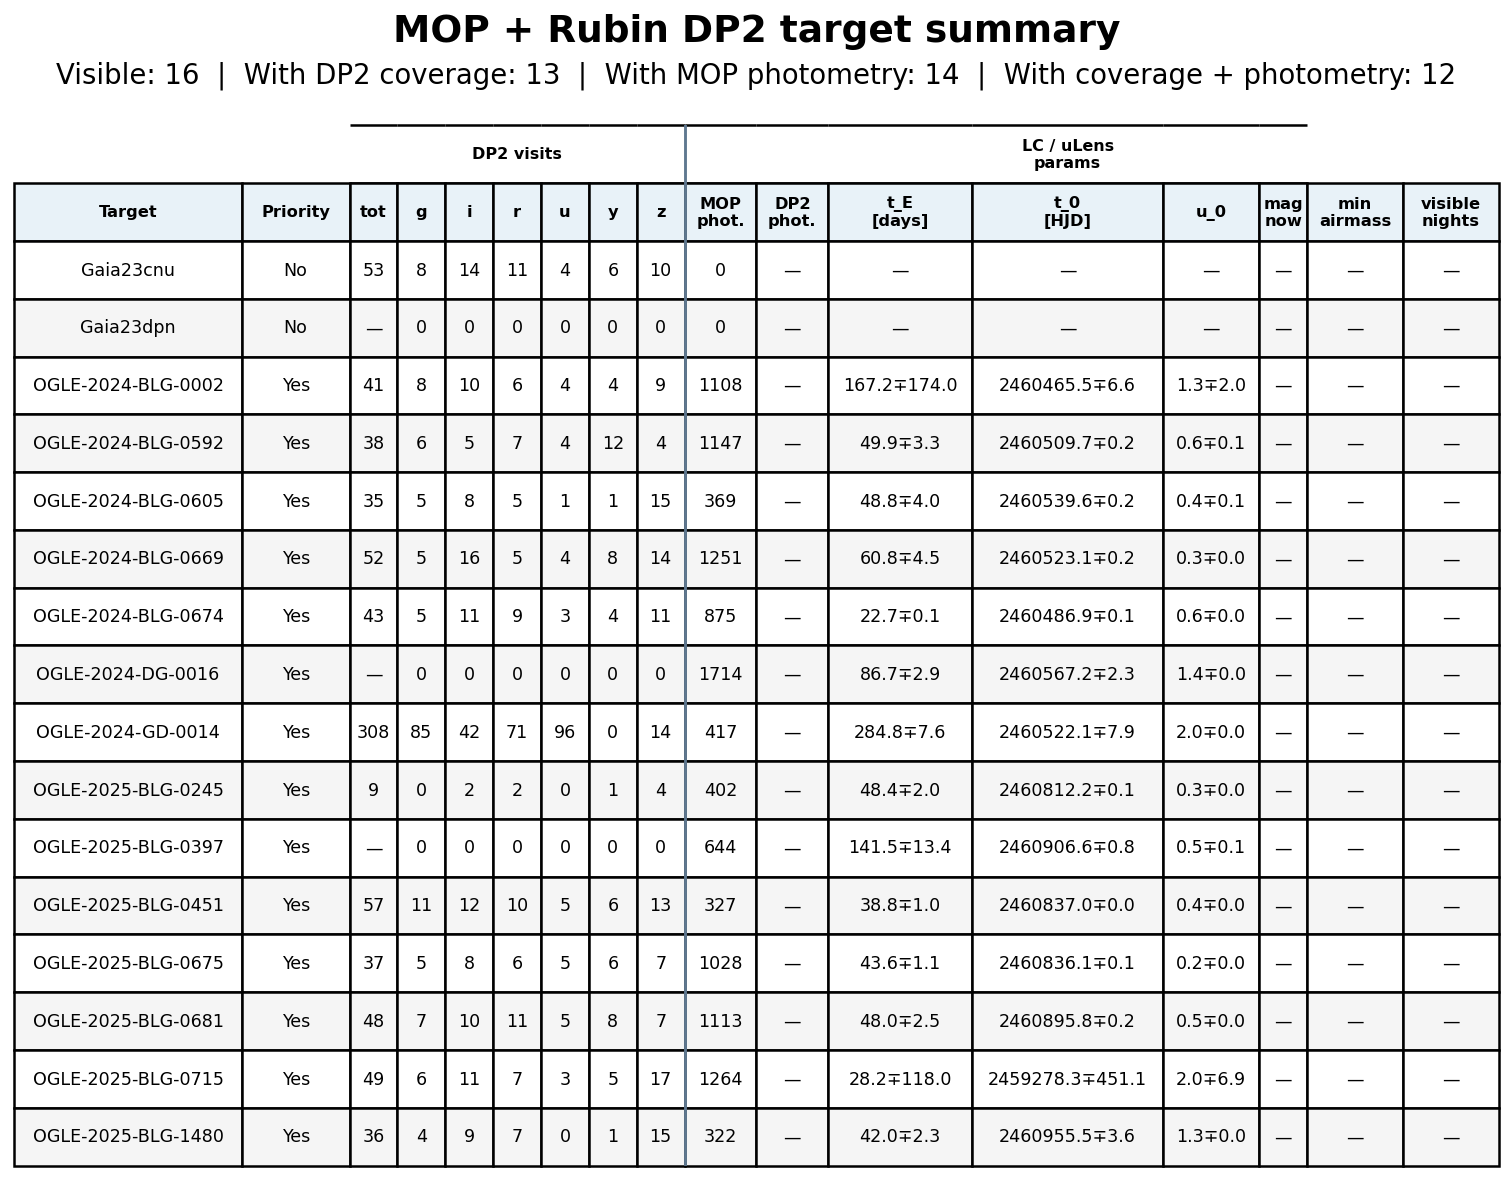

Complete CSV: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/target_summary.csv


In [10]:
summary_png = paths["tables"] / "target_summary.png"
display(Image(filename=str(summary_png)))
print(f"Complete CSV: {(paths['tables'] / 'target_summary.csv').resolve()}")


### Sky maps


In [11]:
map_paths = [
    paths["sky_plots"] / "sky_by_mag_and_visits.png",
    paths["sky_plots"] / "sky_bulge_zoom_mag_and_visits.png",
]
for map_path in map_paths:
    if map_path.exists():
        display(Markdown(f"#### {map_path.stem.replace('_', ' ')}"))


### Individual report examples

Only three reports are displayed by default to keep the notebook compact. Change `MAX_REPORTS_TO_DISPLAY` to display more.


In [12]:
MAX_REPORTS_TO_DISPLAY = 3
report_paths = sorted(paths["targets"].glob("*_target_report.png"))
print(f"Available reports: {len(report_paths)}")
for report_path in report_paths[:MAX_REPORTS_TO_DISPLAY]:
    target_name = report_path.name.removesuffix("_target_report.png")
    display(Markdown(f"#### {target_name}"))
    display(Image(filename=str(report_path), width=1300))


Available reports: 0


### Nightly visibility plots

One plot is generated for every date in the requested range.


Available nightly plots: 10


#### 2026-08-09_visibility

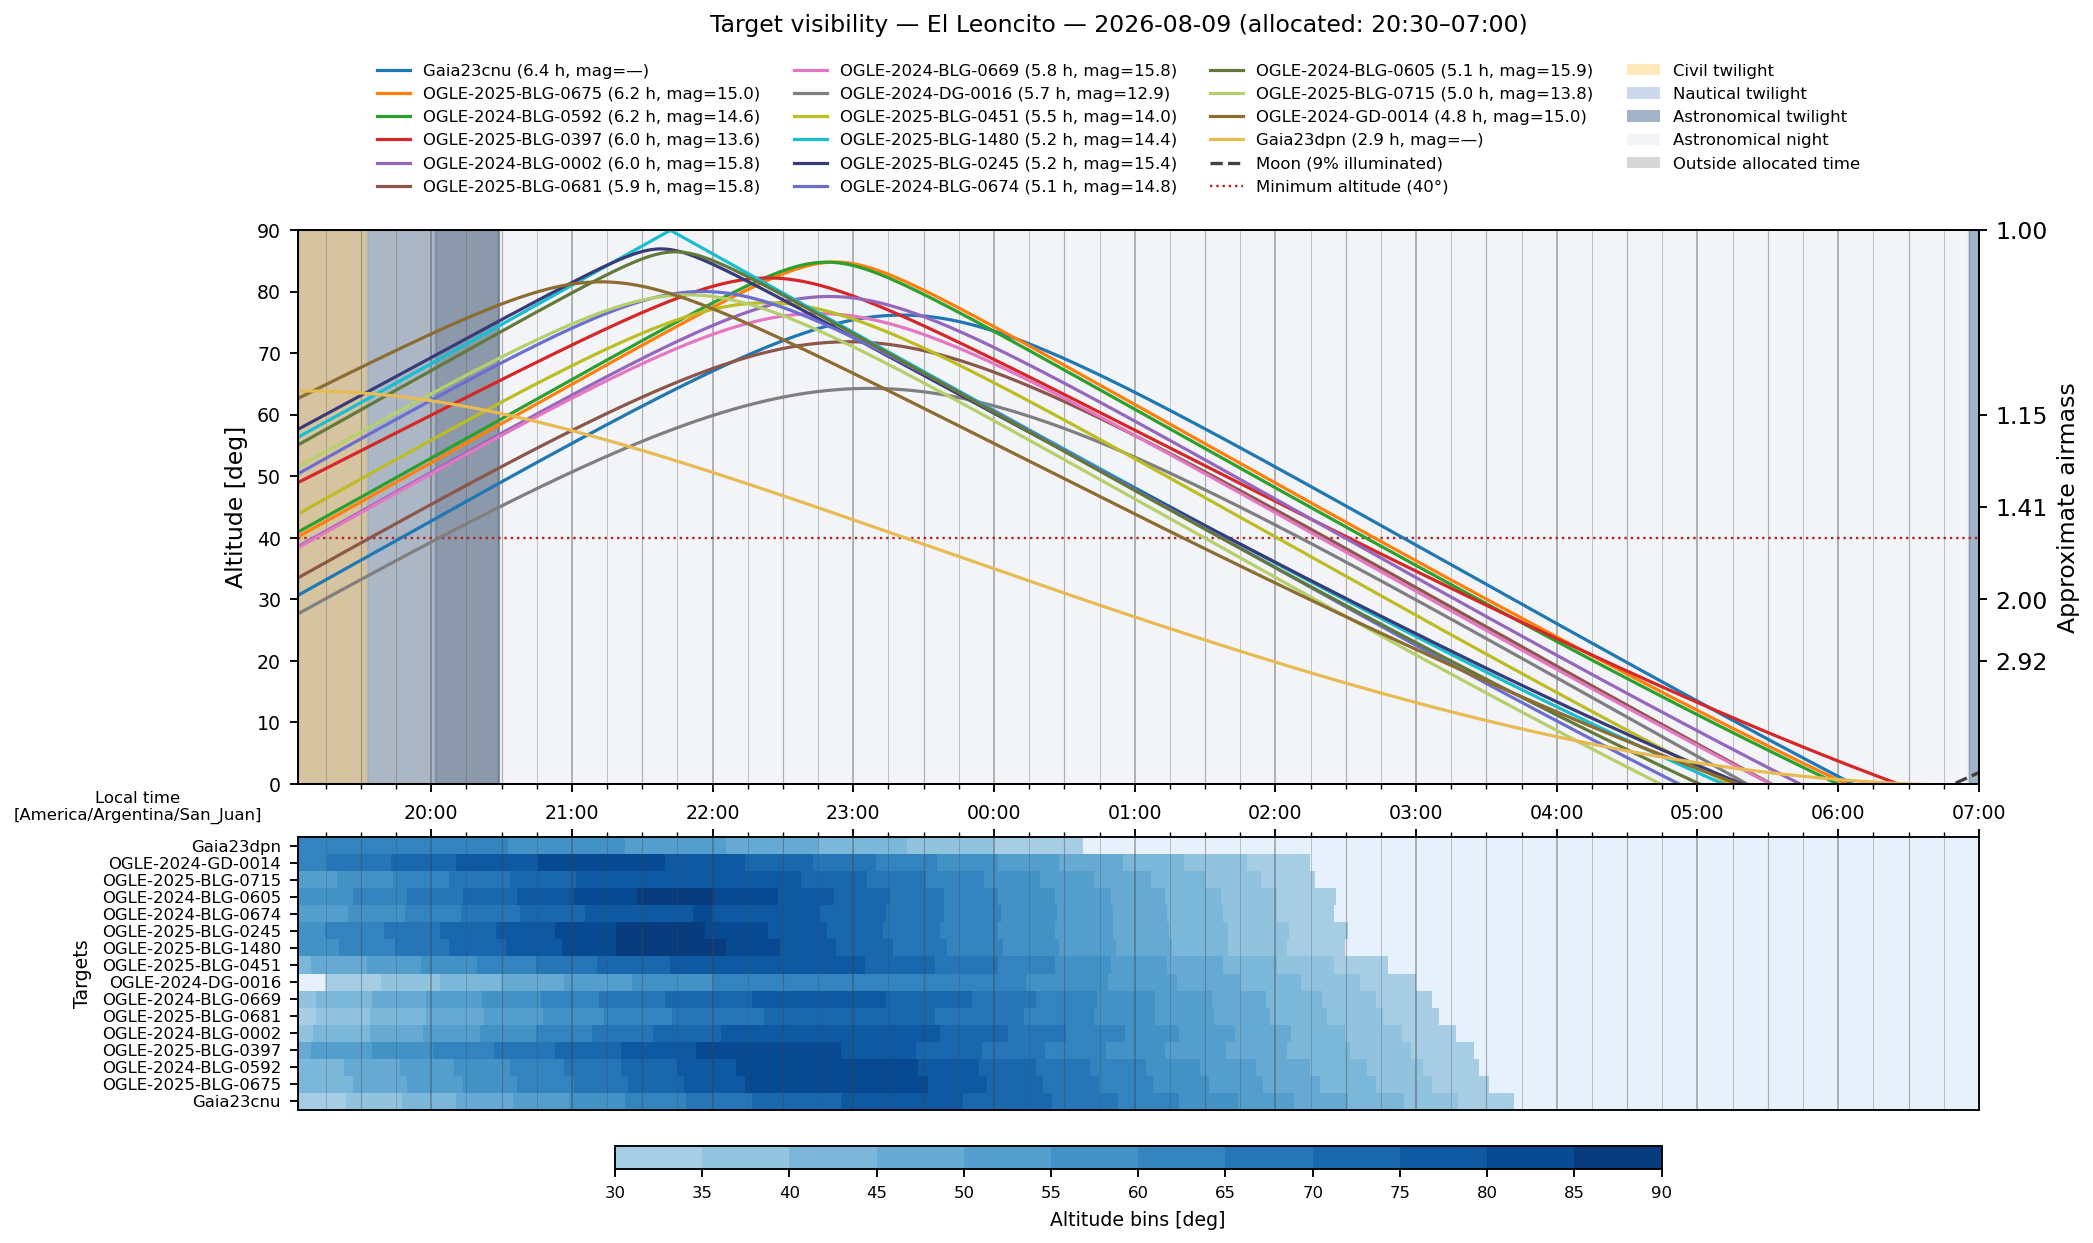

#### 2026-08-10_visibility

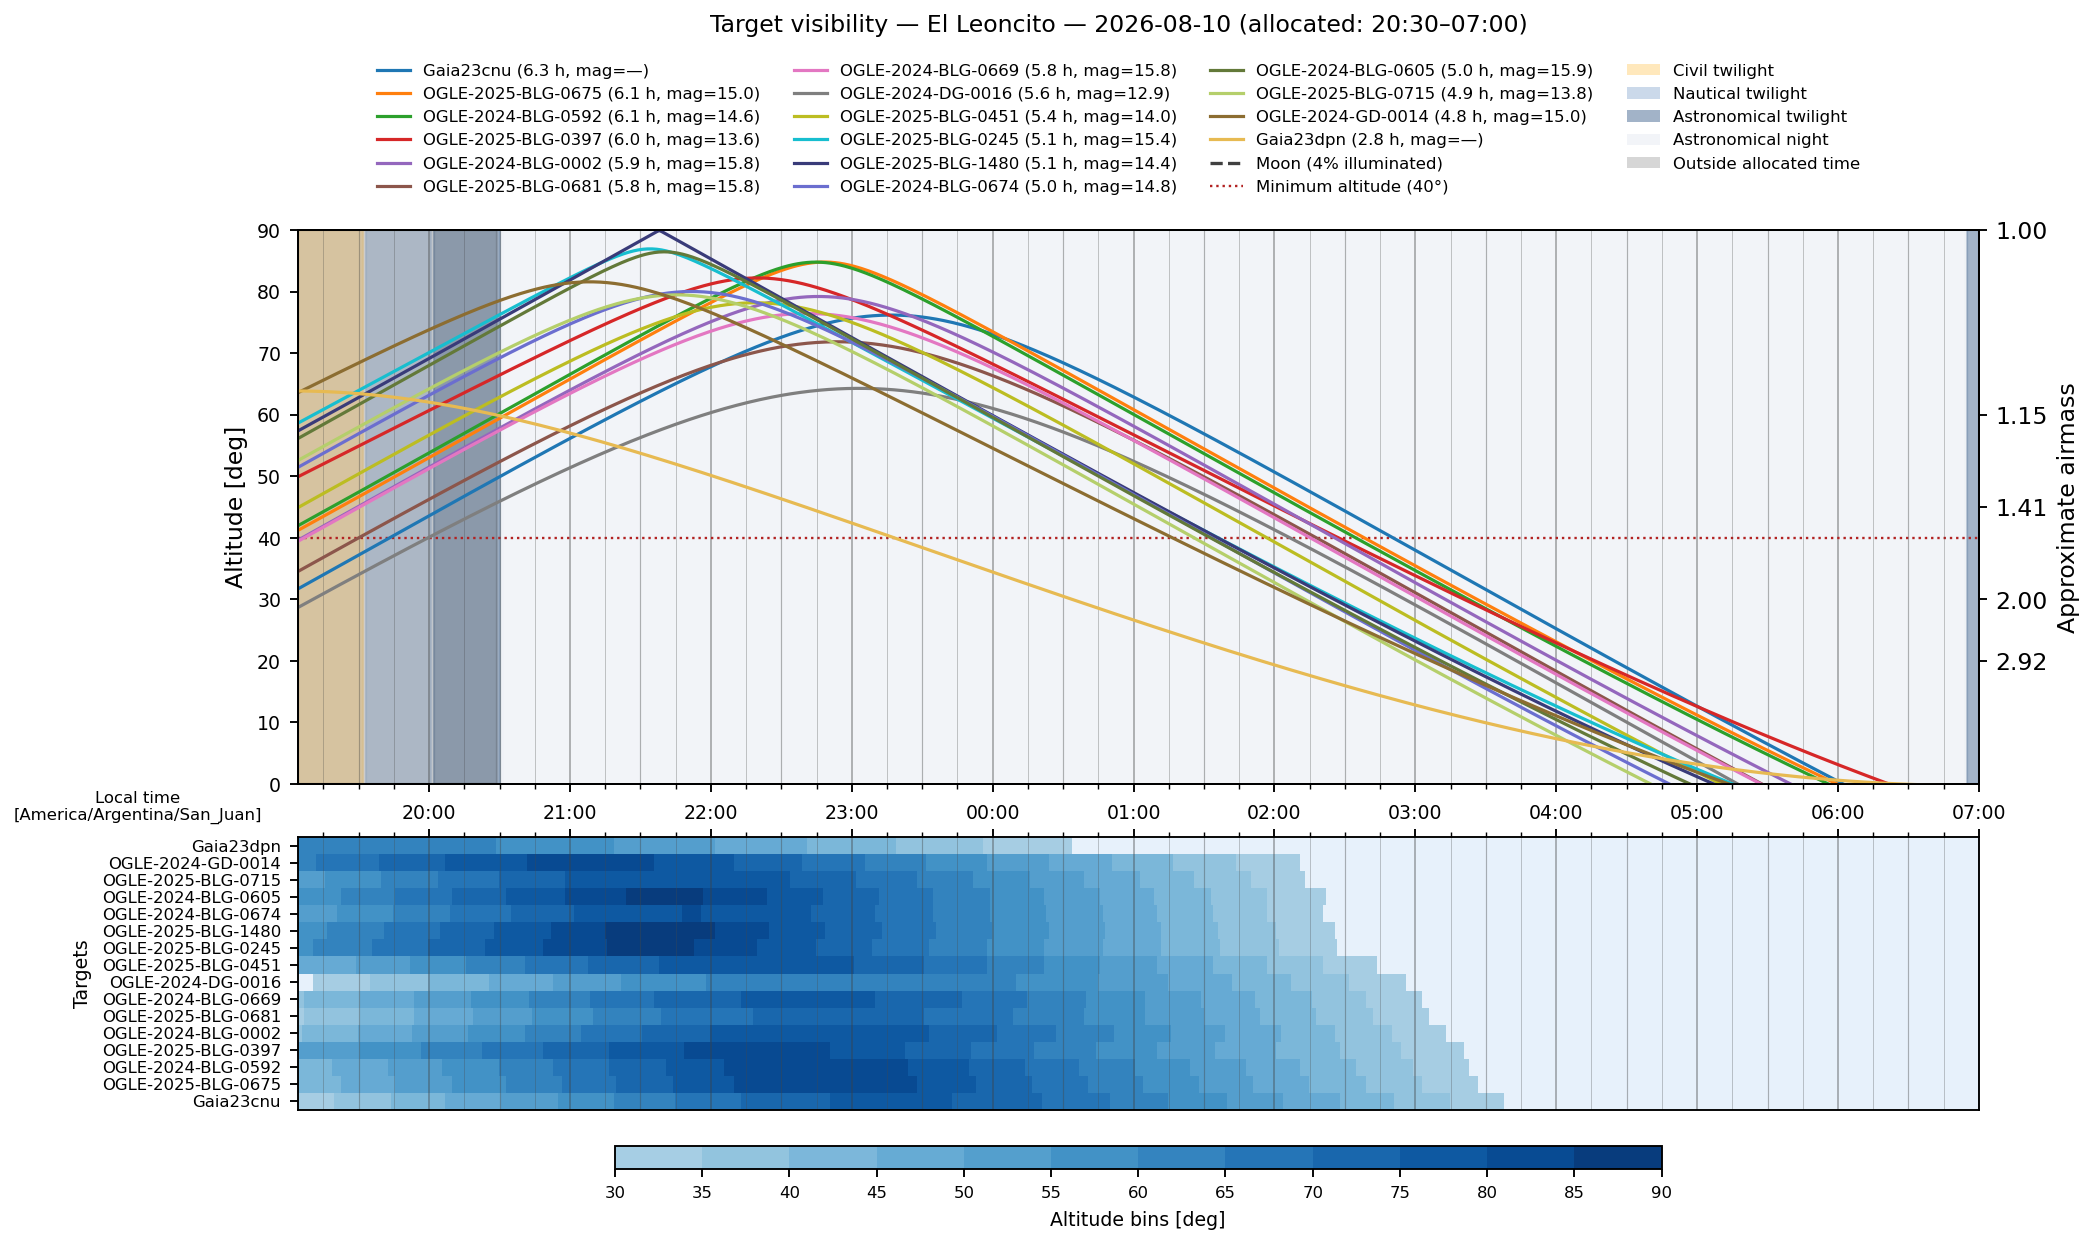

#### 2026-08-11_visibility

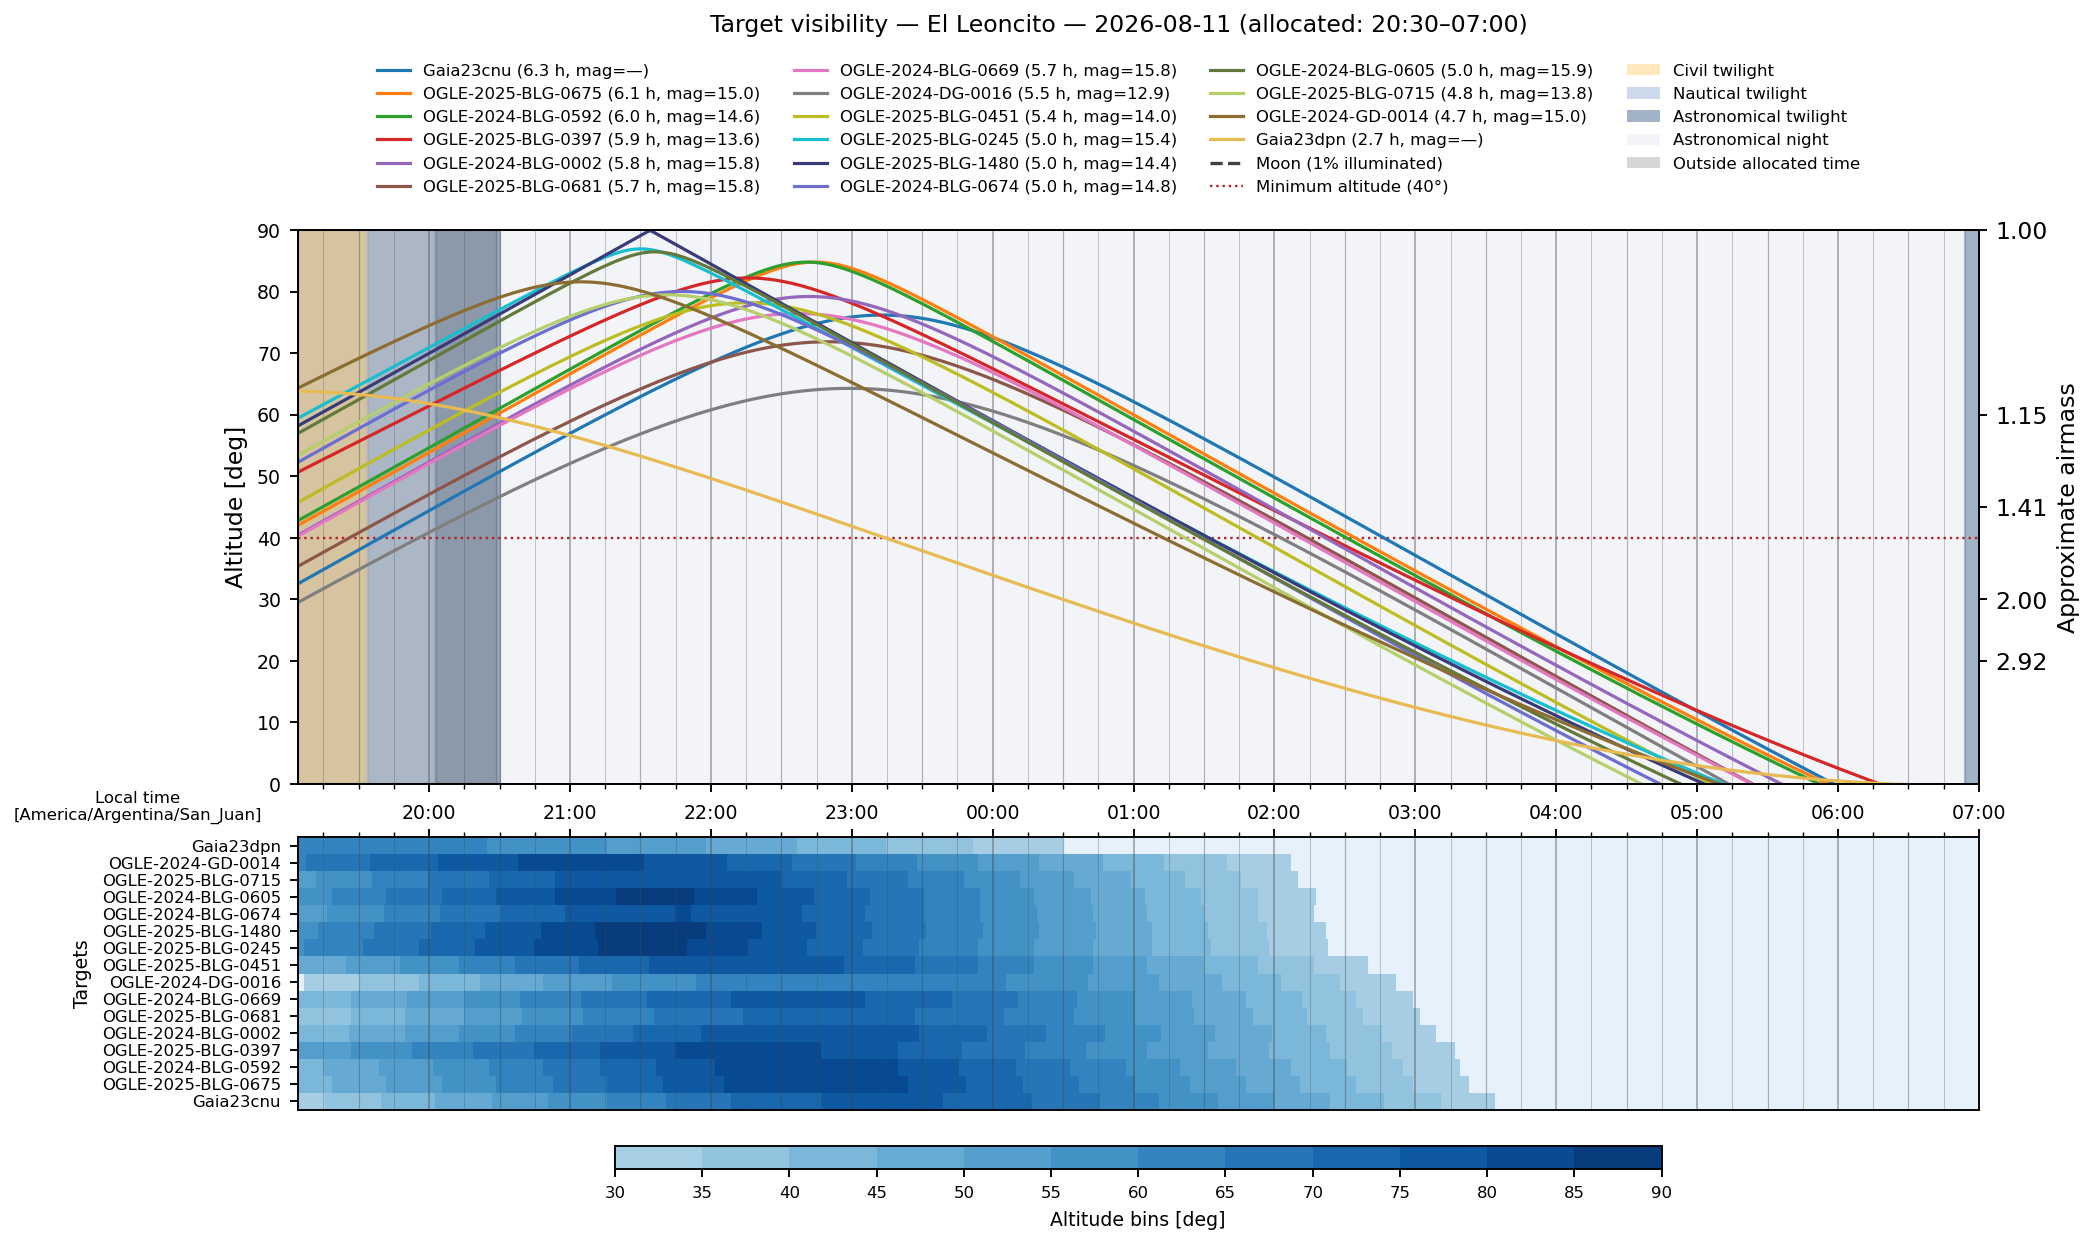

In [13]:
visibility_paths = sorted(paths["visibility_plots"].glob("*_visibility.png"))
print(f"Available nightly plots: {len(visibility_paths)}")
for visibility_path in visibility_paths[:3]:
    display(Markdown(f"#### {visibility_path.stem}"))
    display(Image(filename=str(visibility_path), width=1200))


### Example: review and plot a final nightly selection

This example applies the configurable visibility criteria, displays accepted and rejected targets, and then plots an explicit final subset without applying another filter. Replace the example subset with the targets approved by the observer.


,Target,peak_altitude_deg,observable_night_percent,observable_minutes,selected_for_visibility,visibility_rejection_reasons


Final example selection: 0 targets


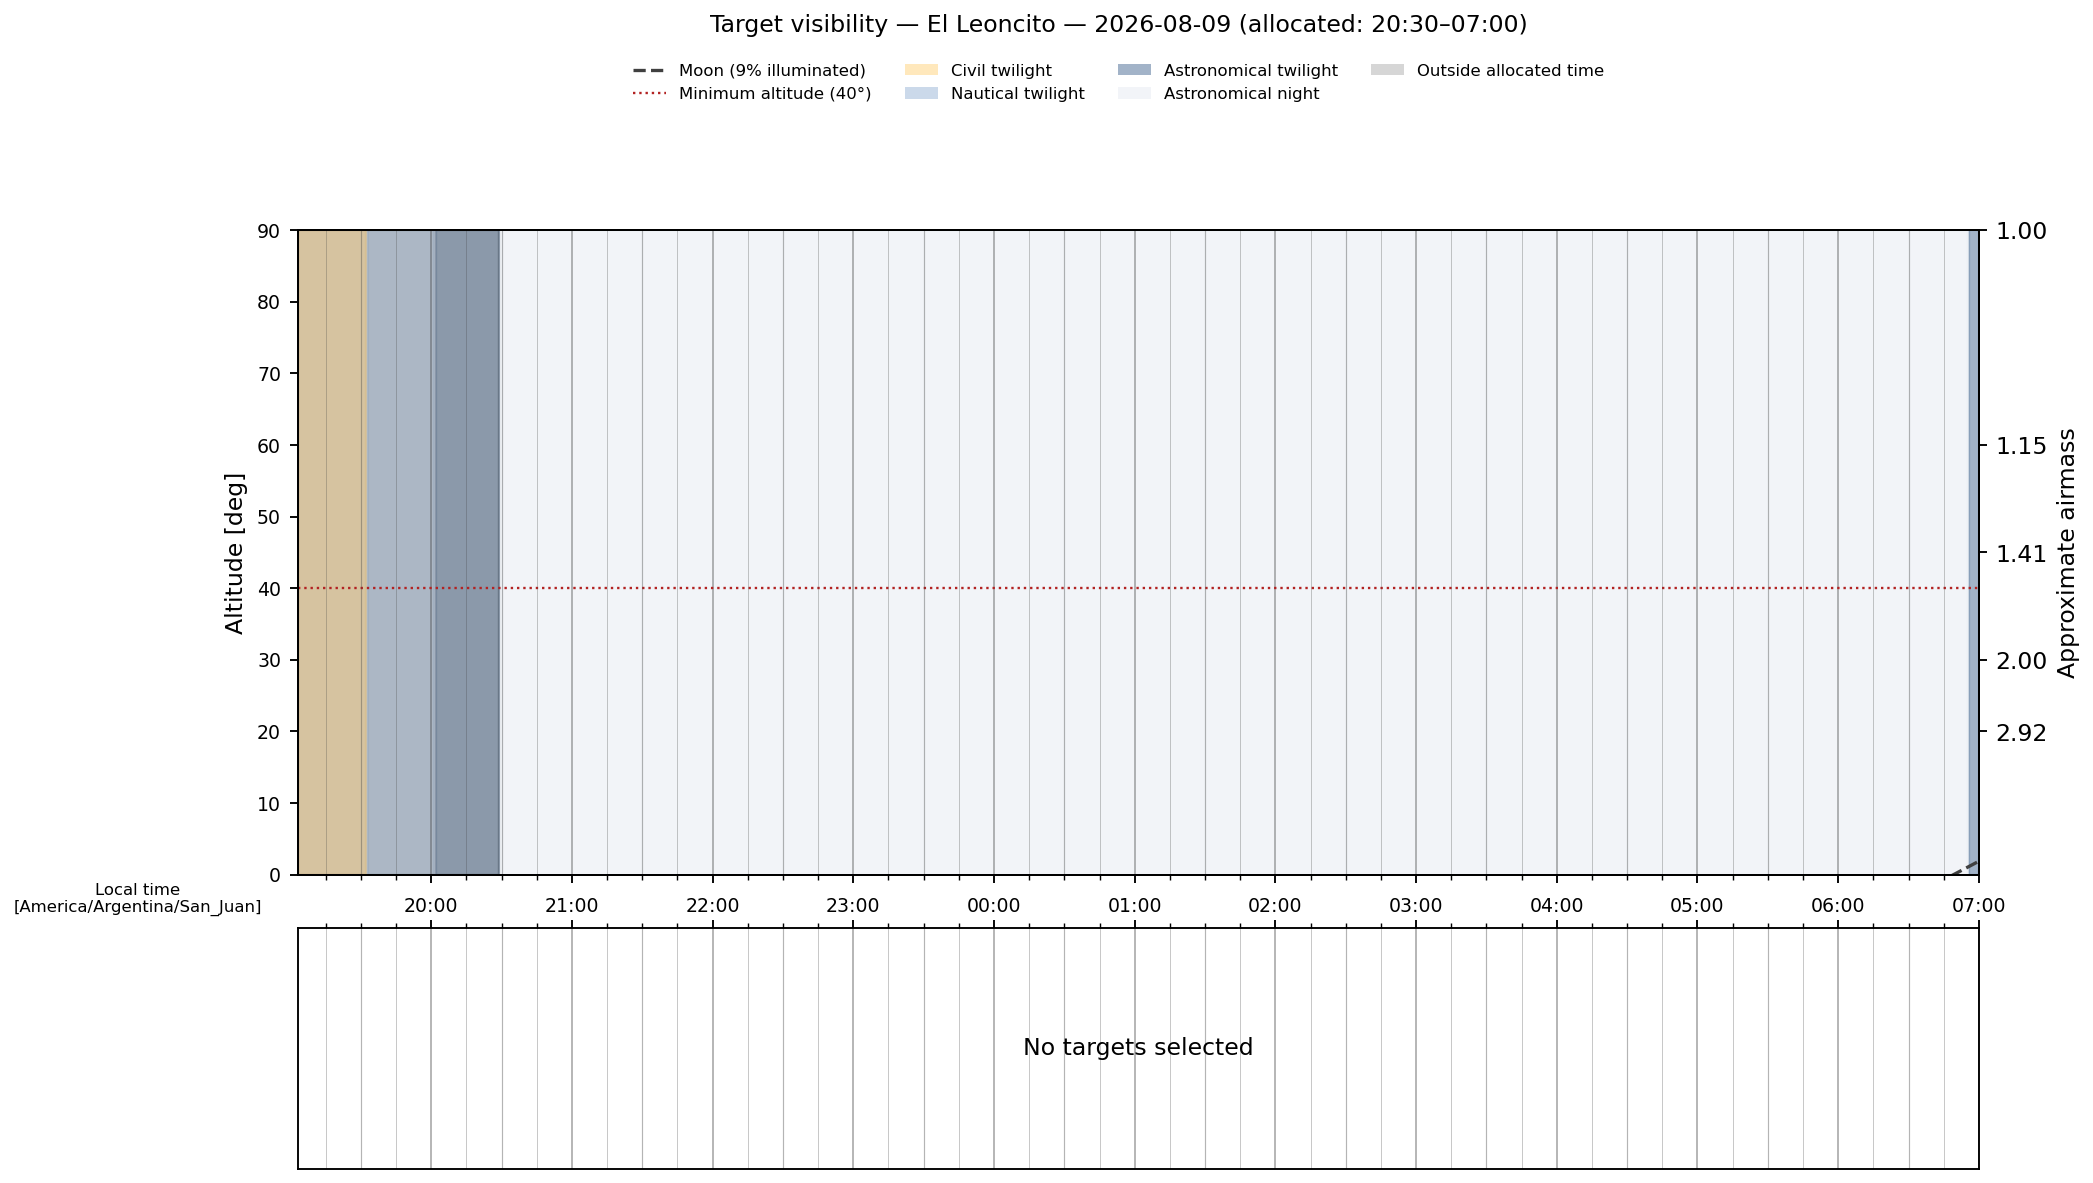

Chronological visibility figure: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/visibility_plots/visibility_sequence.pdf


[Open chronological visibility PDF](/home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/visibility_plots/visibility_sequence.pdf)

In [14]:
from visibility_plotter import (
    plot_selected_visibility,
    plot_visibility_sequence,
    select_nightly_targets,
)

EXAMPLE_NIGHT = START_DATE
FINAL_EXAMPLE_TARGET_COUNT = 12

daily_visibility = pd.read_csv(paths["tables"] / "visible_targets_daily.csv")
night_mask = daily_visibility["observation_date"].astype(str).eq(EXAMPLE_NIGHT)
night_targets = daily_visibility.loc[night_mask].copy()

visibility_candidates = select_nightly_targets(
    night_targets,
    EXAMPLE_NIGHT,
    observatory=OBSERVATORY,
    minimum_altitude=VISIBILITY_MINIMUM_ALTITUDE,
    minimum_observable_minutes=VISIBILITY_MINIMUM_OBSERVABLE_MINUTES,
    time_step_minutes=VISIBILITY_TIME_STEP_MINUTES,
    observing_windows=OBSERVING_WINDOWS,
    return_all=True,
)

display_columns = [
    "Target",
    "peak_altitude_deg",
    "observable_night_percent",
    "observable_minutes",
    "selected_for_visibility",
    "visibility_rejection_reasons",
]
display(visibility_candidates[display_columns].round(1))

# Example observer decision: replace this line with any reviewed target subset.
automatically_selected = visibility_candidates.loc[
    visibility_candidates["selected_for_visibility"]
].copy()
final_selected = automatically_selected.head(FINAL_EXAMPLE_TARGET_COUNT).copy()

final_plot_path = paths["visibility_plots"] / f"{EXAMPLE_NIGHT}_selected_example.png"
plot_selected_visibility(
    final_selected,
    EXAMPLE_NIGHT,
    final_plot_path,
    observatory=OBSERVATORY,
    minimum_altitude=VISIBILITY_MINIMUM_ALTITUDE,
    time_step_minutes=VISIBILITY_TIME_STEP_MINUTES,
    observing_windows=OBSERVING_WINDOWS,
)
print(f"Final example selection: {len(final_selected)} targets")
display(Image(filename=str(final_plot_path), width=1200))

# Chronological multipanel summary of every automatically selected night.
selection_table = pd.read_csv(paths["visibility_plots"] / "visibility_selection.csv")
selected_mask = selection_table["selected_for_visibility"].astype(str).str.lower().eq("true")
selected_sequence = selection_table.loc[selected_mask].copy()
sequence_path = plot_visibility_sequence(
    selected_sequence,
    paths["visibility_plots"] / f"visibility_sequence.{VISIBILITY_SEQUENCE_FORMAT}",
    observatory=OBSERVATORY,
    minimum_altitude=VISIBILITY_MINIMUM_ALTITUDE,
    minimum_observable_minutes=VISIBILITY_MINIMUM_OBSERVABLE_MINUTES,
    time_step_minutes=VISIBILITY_TIME_STEP_MINUTES,
    x_reference_every=VISIBILITY_X_REFERENCE_EVERY,
    output_format=VISIBILITY_SEQUENCE_FORMAT,
    observing_windows=OBSERVING_WINDOWS,
)
print(f"Chronological visibility figure: {sequence_path.resolve()}")
if sequence_path.suffix.lower() == ".png":
    display(Image(filename=str(sequence_path), width=1200))
else:
    display(Markdown(f"[Open chronological visibility PDF]({sequence_path.resolve()})"))


## 4. Technical validation

Checks that MOP parameters are present in the tables and shows where to find the products.


In [15]:
summary_path = paths["tables"] / "visible_summary.csv"
combined_path = paths["tables"] / "combined_targets.csv"
summary_csv = pd.read_csv(summary_path)
combined_csv = pd.read_csv(combined_path)
parameter_columns = [
    column for column in combined.columns
    if column.startswith("mop_")
    and column not in {"mop_link", "mop_parameters_status", "mop_parameters_error"}
]
missing_summary = sorted(set(parameter_columns) - set(summary_csv.columns))
missing_combined = sorted(set(parameter_columns) - set(combined_csv.columns))
if missing_combined:
    raise RuntimeError(f"Missing parameters in combined_targets.csv: {missing_combined}")
if missing_summary:
    print(
        "Note: visible_summary.csv does not contain parameters for targets "
        "outside the MOP-visible snapshot (for example HSH-only targets or "
        "targets excluded by the magnitude cut): " + ", ".join(missing_summary)
    )
status_counts = (
    combined["mop_parameters_status"].value_counts(dropna=False).to_dict()
    if "mop_parameters_status" in combined else {}
)
print(f"MOP page status: {status_counts}")
print(f"Measured parameters: {parameter_columns or 'none'}")
print(f"Reports with coadds: {len(report_paths)}")
print(f"Final table: {combined_path.resolve()}")
print(f"Visual summary: {summary_png.resolve()}")


Note: visible_summary.csv does not contain parameters for targets outside the MOP-visible snapshot (for example HSH-only targets or targets excluded by the magnitude cut): mop_alive, mop_interferometry_candidate, mop_last_fit_jd, mop_latest_data_hjd, mop_latest_data_utc, mop_mag_now, mop_observing_mode, mop_t_0_hjd, mop_t_e_days, mop_tap_priority, mop_tap_priority_longte, mop_u_0
MOP page status: {'available': 14, 'unavailable': 2}
Measured parameters: ['mop_alive', 'mop_observing_mode', 'mop_tap_priority', 'mop_tap_priority_longte', 'mop_interferometry_candidate', 'mop_t_0_hjd', 'mop_u_0', 'mop_t_e_days', 'mop_mag_now', 'mop_latest_data_hjd', 'mop_latest_data_utc', 'mop_last_fit_jd']
Reports with coadds: 0
Final table: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/combined_targets.csv
Visual summary: /home/karennowo/target_selection/outputs/2026-08-09_to_2026-08-18__obs_20-30_to_07-00/tables/target_summary.png
